# Lab: CNN (Transfer Learning) e Autoencoders — Fashion MNIST (Módulo 9)

Exercício genérico da trilha, não usa dado do Projeto Lupa — só pra praticar os conceitos de transfer learning e autoencoder antes de aplicar deep learning ao projeto real (feito na LSTM, no próximo notebook).

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

transformacao = transforms.Compose([transforms.ToTensor()])
treino_completo = torchvision.datasets.FashionMNIST(
    root="../data/raw", train=True, download=True, transform=transformacao
)
teste_completo = torchvision.datasets.FashionMNIST(
    root="../data/raw", train=False, download=True, transform=transformacao
)

# subconjunto - CPU local, sem GPU disponível
treino_sub = Subset(treino_completo, range(8000))
teste_sub = Subset(teste_completo, range(2000))

loader_treino = DataLoader(treino_sub, batch_size=128, shuffle=True)
loader_teste = DataLoader(teste_sub, batch_size=256, shuffle=False)

classes = ["Camiseta", "Calça", "Suéter", "Vestido", "Casaco",
           "Sandália", "Camisa", "Tênis", "Bolsa", "Bota"]

print(f"Treino (subconjunto): {len(treino_sub)} | Teste (subconjunto): {len(teste_sub)}")

Treino (subconjunto): 8000 | Teste (subconjunto): 2000


## CNN com Transfer Learning (ResNet18 pré-treinado)

Ideia do transfer learning: em vez de aprender do zero a "ver" formas e bordas, reaproveitamos uma rede já treinada em milhões de imagens (ImageNet) e só re-treinamos a última camada pra classificar roupas. Isso é bem mais rápido e precisa de bem menos dado.

In [2]:
from torchvision.models import resnet18, ResNet18_Weights

transformacao_resnet = transforms.Compose([
    transforms.Resize(64),
    transforms.Grayscale(num_output_channels=3),  # ResNet espera 3 canais
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

treino_resnet = torchvision.datasets.FashionMNIST(
    root="../data/raw", train=True, download=True, transform=transformacao_resnet
)
teste_resnet = torchvision.datasets.FashionMNIST(
    root="../data/raw", train=False, download=True, transform=transformacao_resnet
)
loader_treino_resnet = DataLoader(Subset(treino_resnet, range(8000)), batch_size=64, shuffle=True)
loader_teste_resnet = DataLoader(Subset(teste_resnet, range(2000)), batch_size=128, shuffle=False)

modelo_cnn = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for parametro in modelo_cnn.parameters():
    parametro.requires_grad = False  # congela a rede pré-treinada

modelo_cnn.fc = nn.Linear(modelo_cnn.fc.in_features, 10)  # só essa camada será treinada

otimizador_cnn = torch.optim.Adam(modelo_cnn.fc.parameters(), lr=1e-3)
perda_cnn = nn.CrossEntropyLoss()

print("Modelo carregado, backbone congelado, treinando só a camada final.")

Modelo carregado, backbone congelado, treinando só a camada final.


In [3]:
N_EPOCAS_CNN = 3

for epoca in range(N_EPOCAS_CNN):
    modelo_cnn.train()
    perda_total = 0.0
    for imagens, rotulos in loader_treino_resnet:
        otimizador_cnn.zero_grad()
        saida = modelo_cnn(imagens)
        perda = perda_cnn(saida, rotulos)
        perda.backward()
        otimizador_cnn.step()
        perda_total += perda.item() * imagens.size(0)
    print(f"Época {epoca+1}/{N_EPOCAS_CNN} - perda: {perda_total/len(loader_treino_resnet.dataset):.4f}")

modelo_cnn.eval()
acertos, total = 0, 0
with torch.no_grad():
    for imagens, rotulos in loader_teste_resnet:
        saida = modelo_cnn(imagens)
        preditos = saida.argmax(dim=1)
        acertos += (preditos == rotulos).sum().item()
        total += rotulos.size(0)

print(f"\nAcurácia no teste (subconjunto): {acertos/total*100:.2f}%")

Época 1/3 - perda: 1.2152


Época 2/3 - perda: 0.7383


Época 3/3 - perda: 0.6448



Acurácia no teste (subconjunto): 77.55%


## Autoencoder — comprimindo e reconstruindo imagens

Um autoencoder aprende a comprimir uma imagem (784 pixels) num vetor pequeno (32 números) e depois reconstruir a imagem original a partir só desse vetor comprimido. Se ele consegue reconstruir bem, é sinal de que aprendeu uma representação útil e compacta da imagem.

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128), nn.ReLU(),
            nn.Linear(128, 28 * 28), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


autoencoder = Autoencoder()
otimizador_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
perda_ae = nn.MSELoss()

N_EPOCAS_AE = 10
for epoca in range(N_EPOCAS_AE):
    autoencoder.train()
    perda_total = 0.0
    for imagens, _ in loader_treino:
        otimizador_ae.zero_grad()
        reconstrucao = autoencoder(imagens)
        perda = perda_ae(reconstrucao, imagens)
        perda.backward()
        otimizador_ae.step()
        perda_total += perda.item() * imagens.size(0)
    print(f"Época {epoca+1}/{N_EPOCAS_AE} - erro de reconstrução (MSE): {perda_total/len(loader_treino.dataset):.5f}")

Época 1/10 - erro de reconstrução (MSE): 0.09312


Época 2/10 - erro de reconstrução (MSE): 0.04681


Época 3/10 - erro de reconstrução (MSE): 0.03433


Época 4/10 - erro de reconstrução (MSE): 0.02758


Época 5/10 - erro de reconstrução (MSE): 0.02515


Época 6/10 - erro de reconstrução (MSE): 0.02367


Época 7/10 - erro de reconstrução (MSE): 0.02266


Época 8/10 - erro de reconstrução (MSE): 0.02186


Época 9/10 - erro de reconstrução (MSE): 0.02101


Época 10/10 - erro de reconstrução (MSE): 0.02043


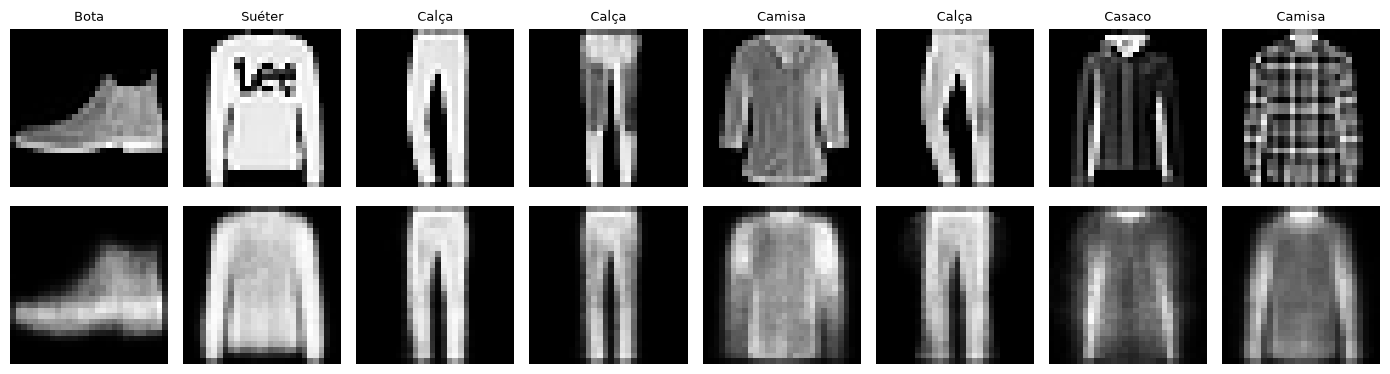

In [5]:
autoencoder.eval()
imagens_teste, rotulos_teste = next(iter(loader_teste))
with torch.no_grad():
    reconstrucoes = autoencoder(imagens_teste[:8])

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(imagens_teste[i][0], cmap="gray")
    axes[0, i].set_title(classes[rotulos_teste[i]], fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstrucoes[i][0], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstruída", fontsize=10)
plt.tight_layout()
plt.show()